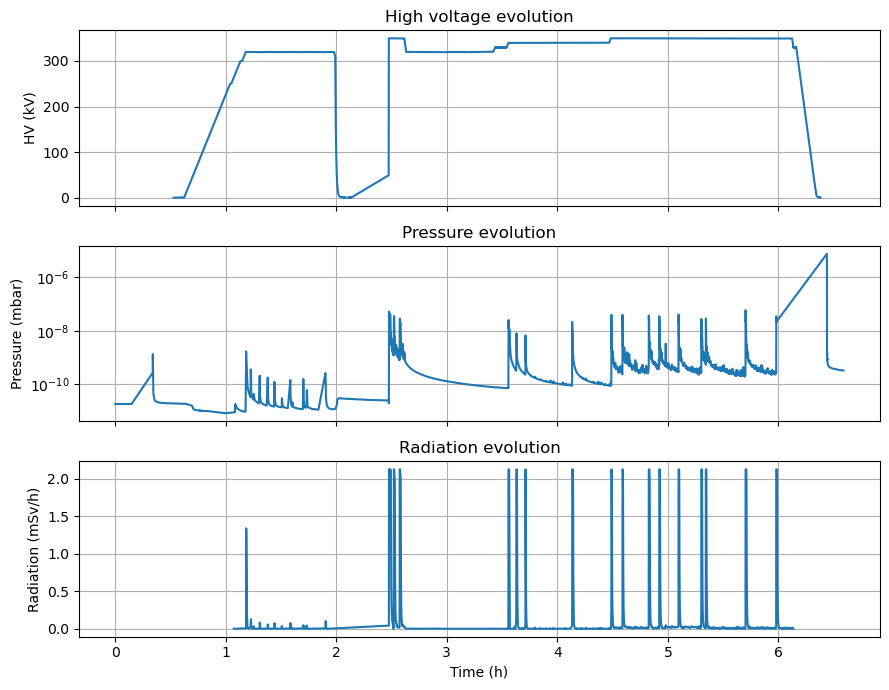

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#Lecture des fichiers CSV et des colonnes de temps
dfV = pd.read_csv("Voltage.csv", sep=";")
dfV["Time"] = pd.to_datetime(
    dfV["Time"],
    format="%Y.%m.%d %H:%M:%S")

dfP = pd.read_csv("Pressure.csv", sep=";")
dfP["Time"] = pd.to_datetime(
    dfP["Time"],
    format="%Y.%m.%d %H:%M:%S")

dfR = pd.read_csv("Radiation.csv", sep=";")
dfR["Time"] = pd.to_datetime(
    dfR["Time"],
    format="%Y.%m.%d %H:%M:%S")

#Définition du temps inital global
dfs=[dfV,dfP,dfR]
t0i = min(df["Time"].min() for df in dfs)

#Création du nouvel axe de temps pour chaque série de données
for df in dfs:
    df["t"] = (df["Time"] - t0i).dt.total_seconds()
    df["t_h"] = df["t"] / 3600

#Nettoyage du graphe de pression
pressure_threshold = 1
dfP_clean = dfP.copy()
dfP_clean.loc[dfP_clean["Pressure"] > pressure_threshold, "Pressure"] = np.nan

#Plots des données
fig, axes = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(9, 7))

axes[0].plot(dfV["t_h"], dfV["Voltage"])
axes[0].set_ylabel("HV (kV)")
axes[0].set_title("High voltage evolution")
axes[0].grid(True)

axes[1].plot(dfP["t_h"], dfP_clean["Pressure"])
axes[1].set_ylabel("Pressure (mbar)")
axes[1].set_yscale("log")
axes[1].set_title("Pressure evolution")
axes[1].grid(True)

axes[2].plot(dfR["t_h"], dfR["Radiation"])
axes[2].set_ylabel("Radiation (mSv/h)")
axes[2].set_xlabel("Time (h)")
axes[2].set_title("Radiation evolution")
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [4]:
t_start = max(dfP_clean["t_h"].min(), dfV["t_h"].min(), dfR["t_h"].min())
t_end   = min(dfP_clean["t_h"].max(), dfV["t_h"].max(), dfR["t_h"].max())

dfP2 = dfP_clean[(dfP_clean["t_h"] >= t_start) & (dfP_clean["t_h"] <= t_end)].copy()
dfV2 = dfV[(dfV["t_h"] >= t_start) & (dfV["t_h"] <= t_end)].copy()
dfR2 = dfR[(dfR["t_h"] >= t_start) & (dfR["t_h"] <= t_end)].copy()

n = min(len(dfP2), len(dfV2), len(dfR2))

dfP2 = dfP2.iloc[:n]
dfV2 = dfV2.iloc[:n]
dfR2 = dfR2.iloc[:n]

df_corr = pd.DataFrame({
    "Voltage": dfV2["Voltage"].values,
    "Pressure": dfP2["Pressure"].values,
    "Rayons X": dfR2["Radiation"].values})

df_corr.corr()

,Voltage,Pressure,Rayons X
Voltage,1.000000,0.047171,0.158896
Pressure,0.047171,1.000000,-0.046378
Rayons X,0.158896,-0.046378,1.000000


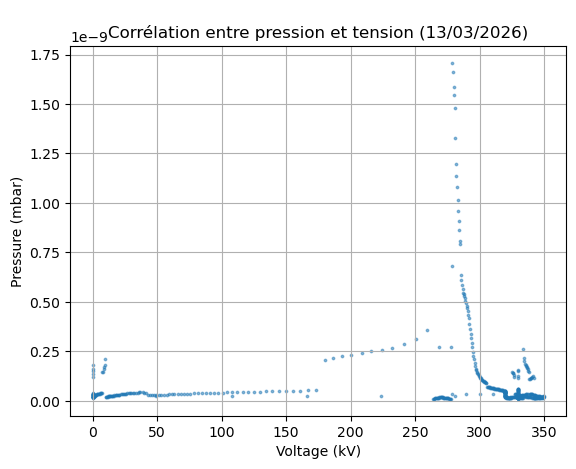

In [5]:
#Corrélation entre pression et tension (P(V))
plt.figure()
plt.scatter(df_corr["Voltage"], df_corr["Pressure"], s=3, alpha=0.5)
plt.xlabel("Voltage (kV)")
plt.ylabel("Pressure (mbar)")
plt.title("Corrélation entre pression et tension (13/03/2026)")
plt.grid()

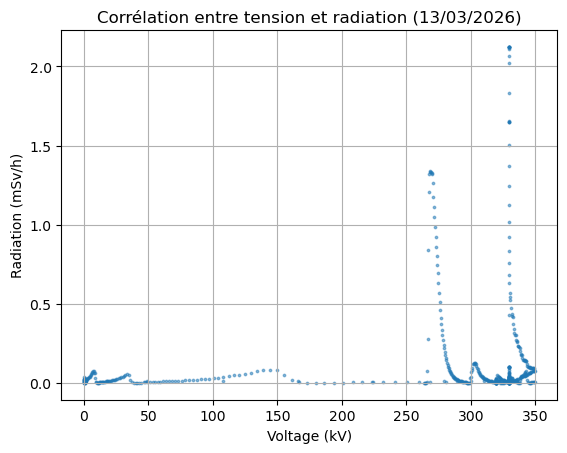

In [6]:
#Corrélation entre radiations et tension (R(V))
plt.figure()
plt.scatter(df_corr["Voltage"], df_corr["Rayons X"], s=3, alpha=0.5)
plt.xlabel("Voltage (kV)")
plt.ylabel("Radiation (mSv/h)")
plt.title("Corrélation entre tension et radiation (13/03/2026)")
plt.grid()

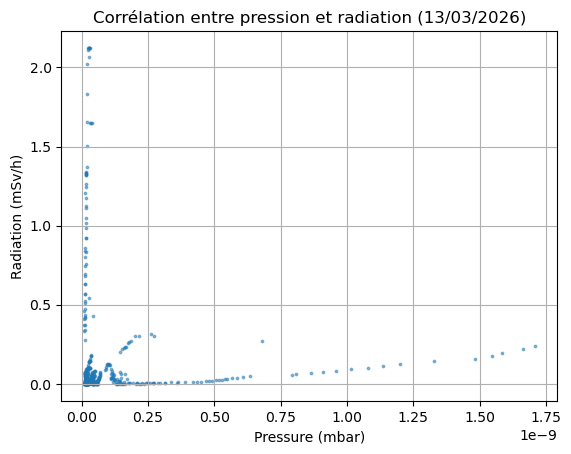

In [7]:
#Corrélation entre pression et radiation (R(P))
plt.figure()
plt.scatter(df_corr["Pressure"], df_corr["Rayons X"], s=3, alpha=0.5)
plt.xlabel("Pressure (mbar)")
plt.ylabel("Radiation (mSv/h)")
plt.title("Corrélation entre pression et radiation (13/03/2026)")
plt.grid()